In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('../data/cleaned_wastewater.csv')

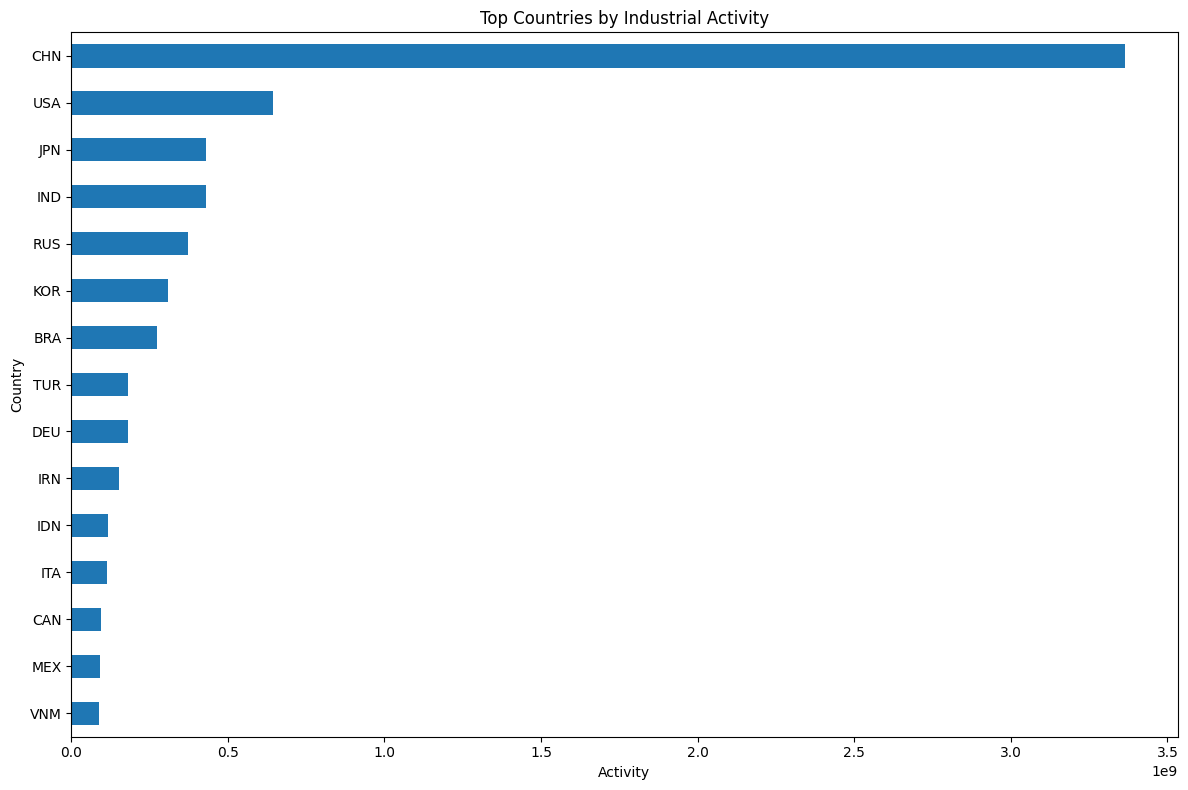

In [3]:
country_activity = (
    df.groupby('iso3_country')['activity']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,8))

country_activity.sort_values().plot(kind='barh')

plt.title('Top Countries by Industrial Activity')

plt.xlabel('Activity')

plt.ylabel('Country')

plt.tight_layout()

plt.savefig(
    '../visualizations/top_countries_activity.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

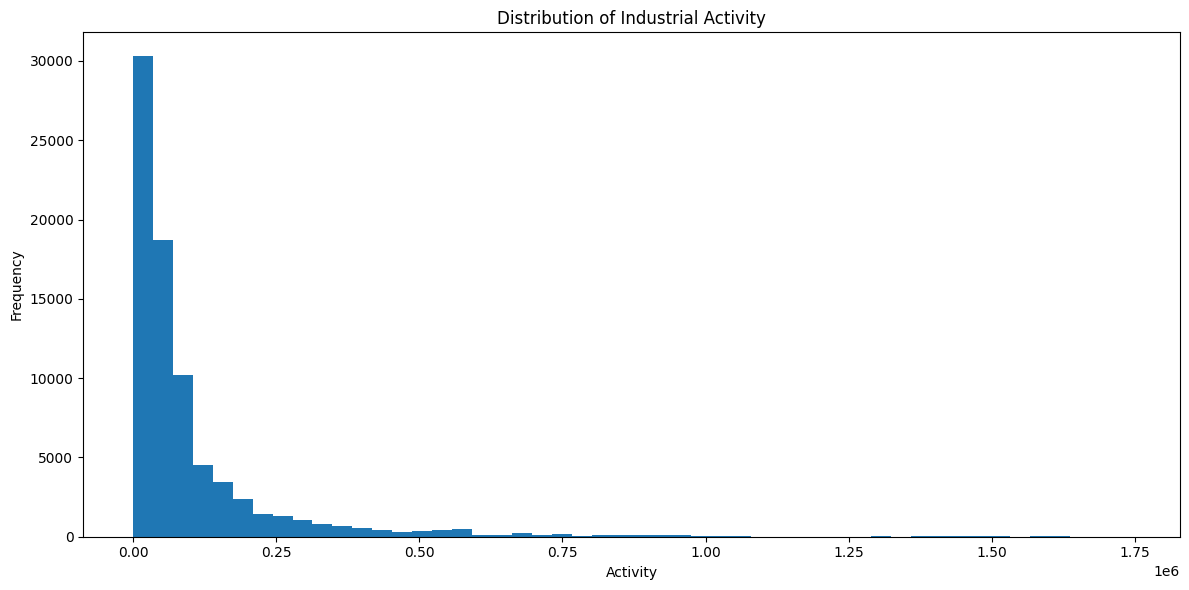

In [4]:
plt.figure(figsize=(12,6))

plt.hist(
    df['activity'],
    bins=50
)

plt.title('Distribution of Industrial Activity')

plt.xlabel('Activity')

plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    '../visualizations/activity_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

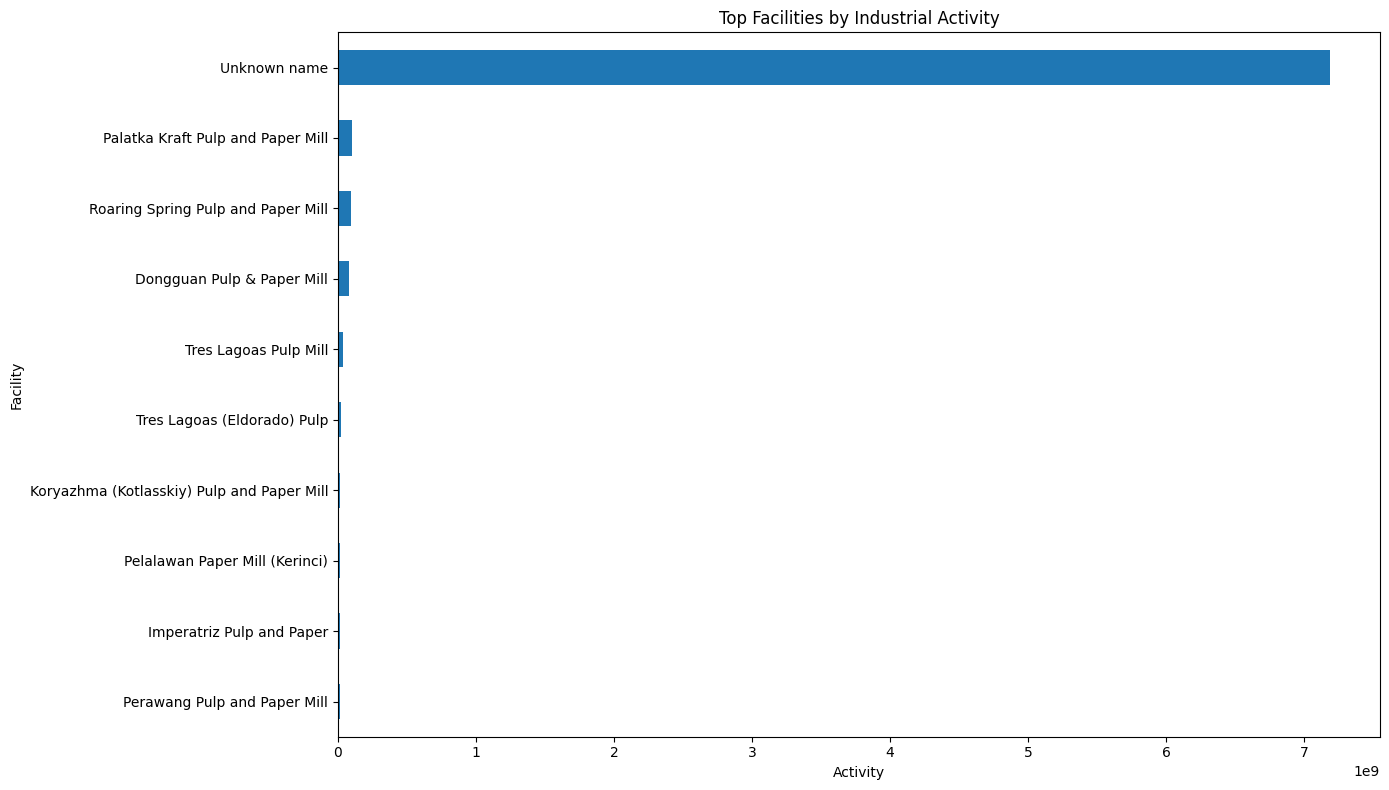

In [5]:
top_facilities = (
    df.groupby('source_name')['activity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,8))

top_facilities.sort_values().plot(kind='barh')

plt.title('Top Facilities by Industrial Activity')

plt.xlabel('Activity')

plt.ylabel('Facility')

plt.tight_layout()

plt.savefig(
    '../visualizations/top_facilities.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

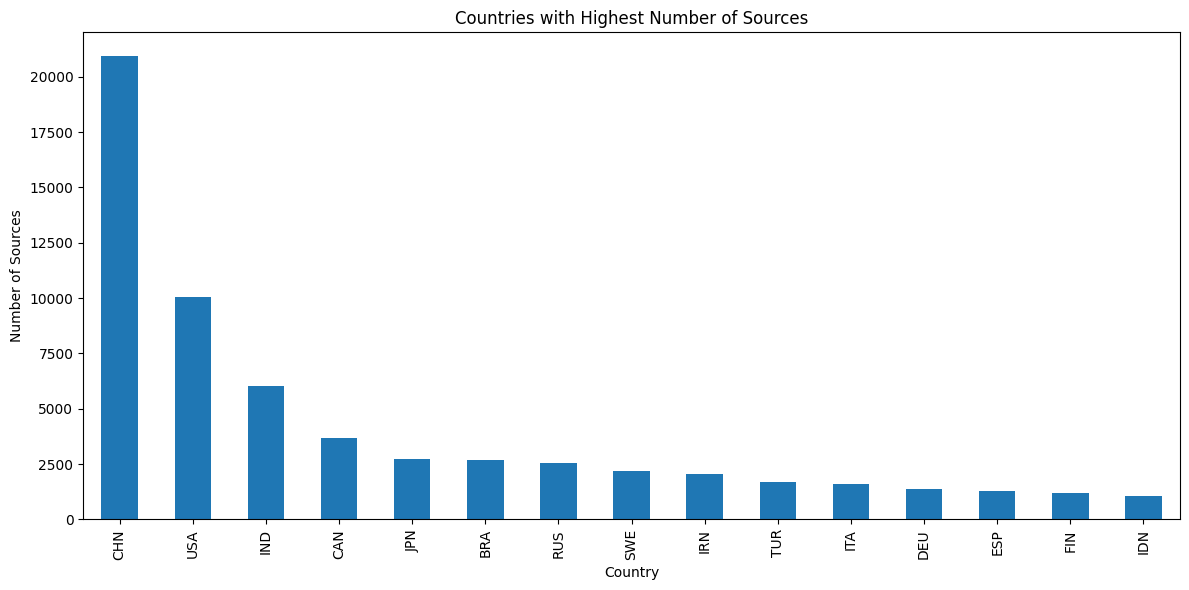

In [6]:
country_sources = (
    df['iso3_country']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

country_sources.plot(kind='bar')

plt.title('Countries with Highest Number of Sources')

plt.xlabel('Country')

plt.ylabel('Number of Sources')

plt.tight_layout()

plt.savefig(
    '../visualizations/country_source_count.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

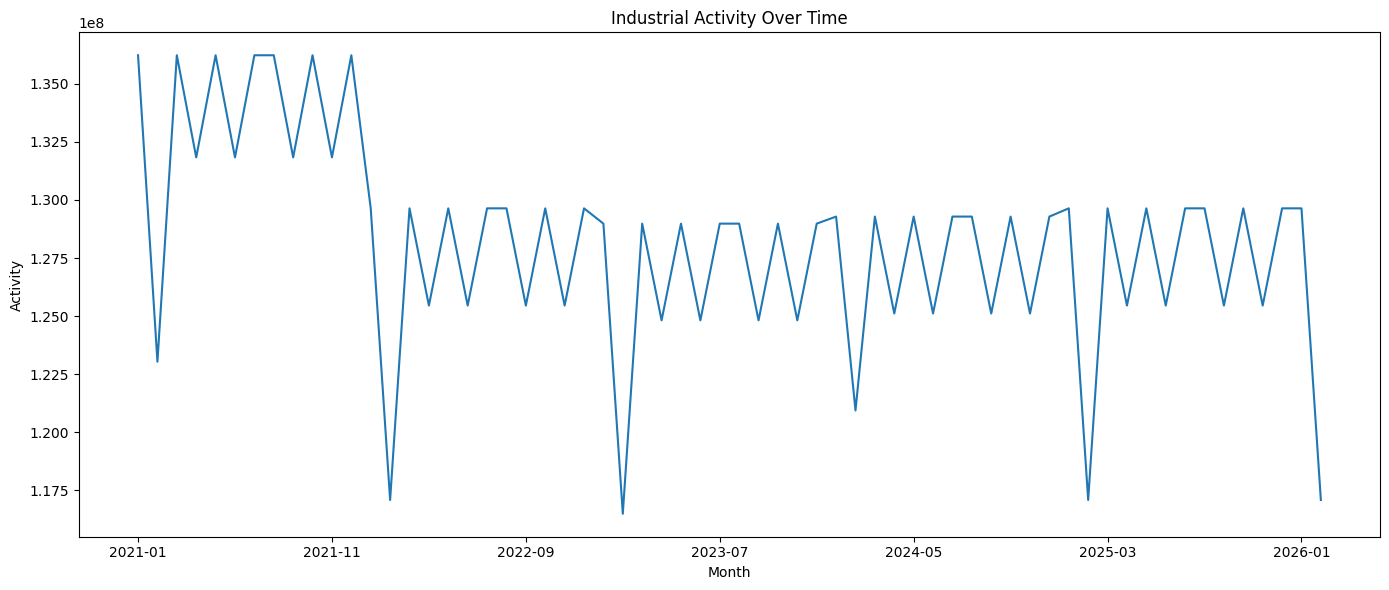

In [7]:
df['start_time'] = pd.to_datetime(df['start_time'])

monthly_activity = (
    df.groupby(df['start_time'].dt.to_period('M'))['activity']
    .sum()
)

monthly_activity.index = monthly_activity.index.astype(str)

plt.figure(figsize=(14,6))

monthly_activity.plot()

plt.title('Industrial Activity Over Time')

plt.xlabel('Month')

plt.ylabel('Activity')

plt.tight_layout()

plt.savefig(
    '../visualizations/activity_over_time.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

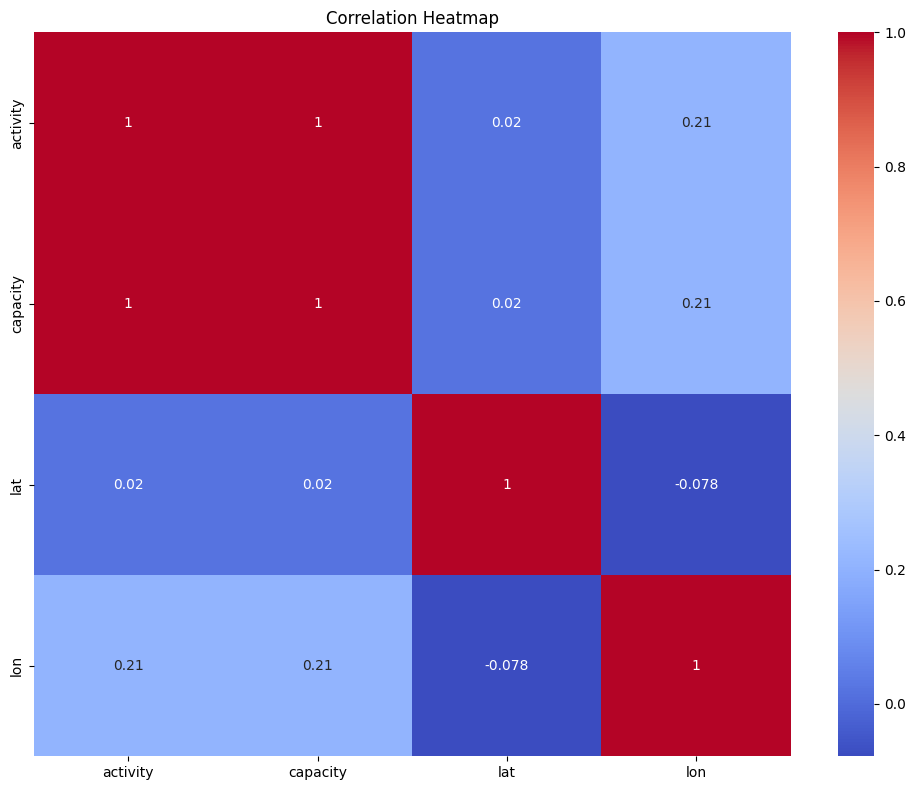

In [8]:
numeric_cols = [
    'activity',
    'capacity',
    'lat',
    'lon'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.savefig(
    '../visualizations/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

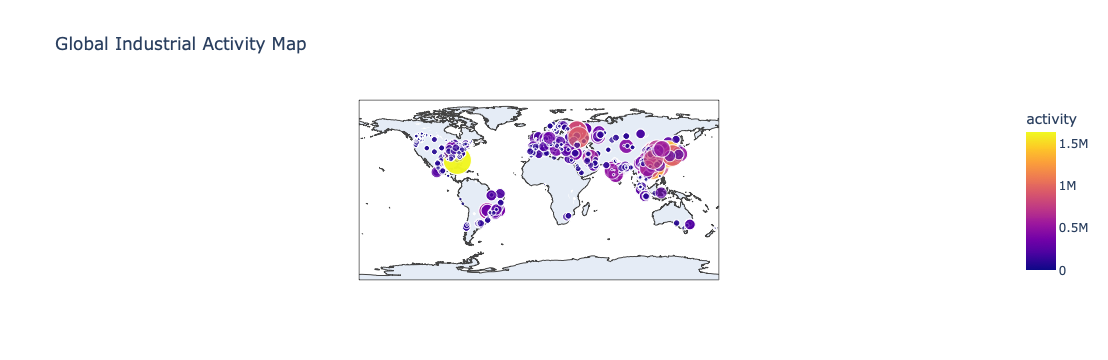

In [10]:
sample_df = df.sample(3000)

fig = px.scatter_geo(
    sample_df,
    lat='lat',
    lon='lon',
    size='activity',
    color='activity',
    hover_name='iso3_country',
    title='Global Industrial Activity Map'
)

fig.write_image(
    '../visualizations/global_activity_map.png',
    scale=3
)

fig.show()

In [11]:
import os

os.listdir('../visualizations')

['activity_distribution.png',
 'activity_over_time.png',
 'top_facilities.png',
 'correlation_heatmap.png',
 'global_activity_map.png',
 'country_source_count.png',
 'top_countries_activity.png']